<a href="https://colab.research.google.com/github/atieh-ameri/fitts-law-experiment/blob/main/Fitts_Law_Experiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
### Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [66]:
### Read data

url = "https://raw.githubusercontent.com/atieh-ameri/fitts-law-experiment/main/raw_data.csv"
df = pd.read_csv(url)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,participant_id,session_start_iso,handedness,proficiency,age,block,block_time_s,trial,amplitude_px,direction,diameter_px,radius_px,errors,path_distance_px,center_to_click_px,trial_time_s
0,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,1,180,left,40,20,0,181.55,169.01,1.0111
1,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,2,180,right,40,20,0,192.85,181.10,0.7690
2,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,3,260,right,80,40,0,280.15,261.02,0.7817
3,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,4,500,right,80,40,0,634.07,503.08,1.2399
4,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,5,500,left,80,40,0,486.96,484.01,1.2039


In [67]:
### Create index of difficulty
df["ID"] = np.log2(df["amplitude_px"] / df["diameter_px"] + 1)
df

,participant_id,session_start_iso,handedness,proficiency,age,block,block_time_s,trial,amplitude_px,direction,diameter_px,radius_px,errors,path_distance_px,center_to_click_px,trial_time_s,ID
0,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,1,180,left,40,20,0,181.55,169.01,1.0111,2.459432
1,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,2,180,right,40,20,0,192.85,181.10,0.7690,2.459432
2,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,3,260,right,80,40,0,280.15,261.02,0.7817,2.087463
3,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,4,500,right,80,40,0,634.07,503.08,1.2399,2.857981
4,44319,2025-11-18T18:54:27,Right-handed,Rarely use mouse,20,1,52.8677,5,500,left,80,40,0,486.96,484.01,1.2039,2.857981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,866197,2025-11-17T15:29:04,Right-handed,Regular user,37,10,52.1858,28,260,left,40,20,0,246.99,244.00,0.9810,2.906891
4796,866197,2025-11-17T15:29:04,Right-handed,Regular user,37,10,52.1858,29,260,left,160,80,0,236.42,236.01,0.6812,1.392317
4797,866197,2025-11-17T15:29:04,Right-handed,Regular user,37,10,52.1858,30,260,left,120,60,0,244.94,242.03,1.4137,1.662965
4798,866197,2025-11-17T15:29:04,Right-handed,Regular user,37,10,52.1858,31,180,right,40,20,0,192.36,191.13,1.3975,2.459432


# Demographics

## Handedness Count

In [68]:
hand_counts = (
    df.groupby("handedness")["participant_id"]
      .nunique()
      .reset_index(name="n_participants")
)

print(hand_counts)

     handedness  n_participants
0   Left-handed               2
1  Right-handed              13


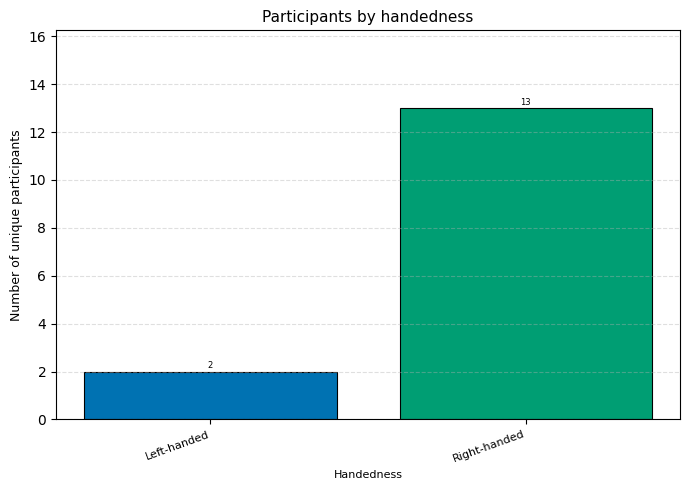

In [69]:

# hand_counts has columns: 'handedness', 'n_participants'

x = np.arange(len(hand_counts))
heights = hand_counts["n_participants"].values
labels = hand_counts["handedness"].values

# blue / green colors
colors = ['#0072B2', '#009E73']  # blue, green
bar_colors = [colors[i % len(colors)] for i in range(len(x))]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    x,
    heights,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

# show number above each bar
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f"{h:.0f}",
        ha="center",
        va="bottom",
        fontsize=6
    )

# y-limit = 1.25 * max
y_max = heights.max()
ax.set_ylim(0, y_max * 1.25)

ax.set_xticks(x, )

plt.xticks(x, labels, fontsize=8, rotation=0)

ax.set_xlabel("Handedness", fontsize=8)
ax.set_ylabel("Number of unique participants", fontsize=9)
ax.set_title("Participants by handedness", fontsize=11)
plt.xticks(x, labels, rotation=20, ha="right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Mouse Proficiency Level Count of Participants

        proficiency  n_participants
0       Casual user               2
1        Power user               3
2  Rarely use mouse               4
3      Regular user               6


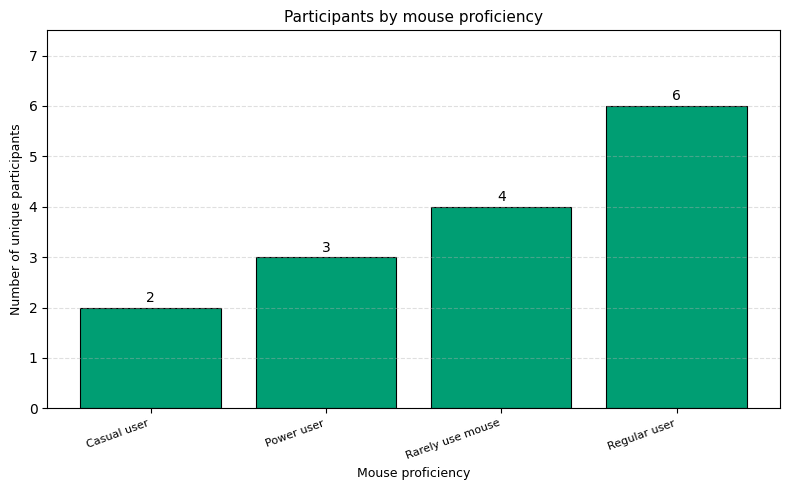

In [71]:
# Unique participants per mouse proficiency
prof_counts = (
    df.groupby("proficiency")["participant_id"]
      .nunique()
      .reset_index(name="n_participants")
)

print(prof_counts)

# Prepare data
x = np.arange(len(prof_counts))  # positions
heights = prof_counts["n_participants"].values
labels = prof_counts["proficiency"].values

# blue / green palette
colors = ['#009E73']
bar_colors = [colors[i % len(colors)] for i in range(len(x))]

plt.figure(figsize=(8, 5))

# Bar chart
bars = plt.bar(x, heights, color=bar_colors, edgecolor='black', linewidth=0.8)

# Add numbers on top of each bar (smaller font)
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f"{h:.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Set y-limit to 1.25×max
y_max = heights.max()
plt.ylim(0, y_max * 1.25)

# Labels, title, ticks (slightly smaller fonts)
plt.xticks(x, labels, rotation=20, ha="right", fontsize=8)
plt.xlabel("Mouse proficiency", fontsize=9)
plt.ylabel("Number of unique participants", fontsize=9)
plt.title("Participants by mouse proficiency", fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

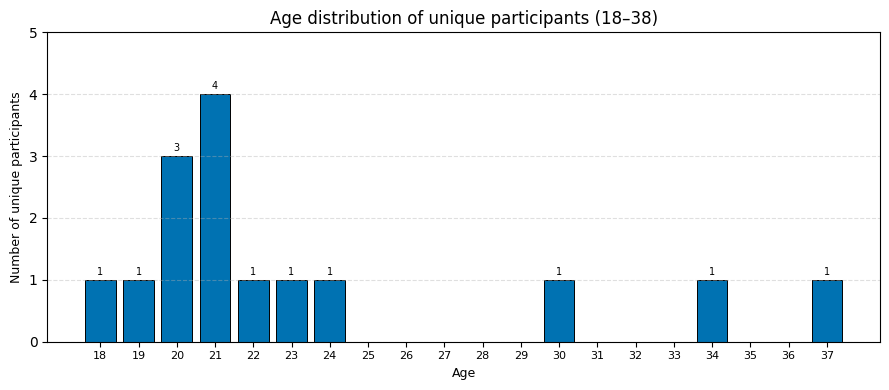

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# One row per unique participant
participants = df[["participant_id", "age"]].drop_duplicates("participant_id")

# Make sure age is numeric
participants["age"] = participants["age"].astype(int)

# Keep only ages in [18, 42]
age_filtered = participants[participants["age"].between(18, 37)]

# Build counts for every age from 18 to 42 (42 included)
age_range = np.arange(18, 38)  # 18, 19, ..., 42
age_counts = (
    age_filtered["age"]
    .value_counts()
    .reindex(age_range, fill_value=0)   # ensure all ages appear, even if count 0
)

# Plot
x = np.arange(len(age_counts))
heights = age_counts.values
labels = age_counts.index.astype(str)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(x, heights, color="#0072B2", edgecolor="black", linewidth=0.7)

for b in bars:
    h = b.get_height()
    if h > 0:   # only label non-zero bars
        ax.text(b.get_x() + b.get_width()/2, h + 0.05, f"{int(h)}",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_xlabel("Age", fontsize=9)
ax.set_ylabel("Number of unique participants", fontsize=9)
ax.set_title("Age distribution of unique participants (18–38)")

y_max = heights.max() if len(heights) > 0 else 1
ax.set_ylim(0, y_max * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Original Table with Raw Data

In [73]:

summary = (
    df.groupby(["amplitude_px", "diameter_px"])
      .agg (
          ID=("ID", "mean"),

          avg_trial_time=("trial_time_s", "mean"),
          avg_path_distance=("path_distance_px", "mean"),
          total_errors=("errors", "sum"),
          n_trials=("errors", "count"),
          )
)

summary["Error_Rate"]= summary["total_errors"]* 100/(summary["n_trials"]*15)
summary = summary.reset_index()
summary = summary[[ "diameter_px", "amplitude_px","ID", "avg_trial_time", "avg_path_distance", "Error_Rate"  ]]

cols_to_round = ["avg_trial_time", "avg_path_distance", "Error_Rate", "ID"]
summary[cols_to_round] = summary[cols_to_round].round(2)

summary


,diameter_px,amplitude_px,ID,avg_trial_time,avg_path_distance,Error_Rate
0,40,180,2.46,2.50,239.16,1.33
1,80,180,1.70,0.93,221.09,1.24
2,120,180,1.32,0.83,191.17,1.44
3,160,180,1.09,0.76,195.67,1.00
4,40,260,2.91,1.17,322.14,1.49
5,80,260,2.09,1.08,310.96,1.56
6,120,260,1.66,0.96,295.50,1.07
7,160,260,1.39,0.86,269.50,1.16
8,40,360,3.32,1.26,433.74,1.29
9,80,360,2.46,1.15,415.83,1.38


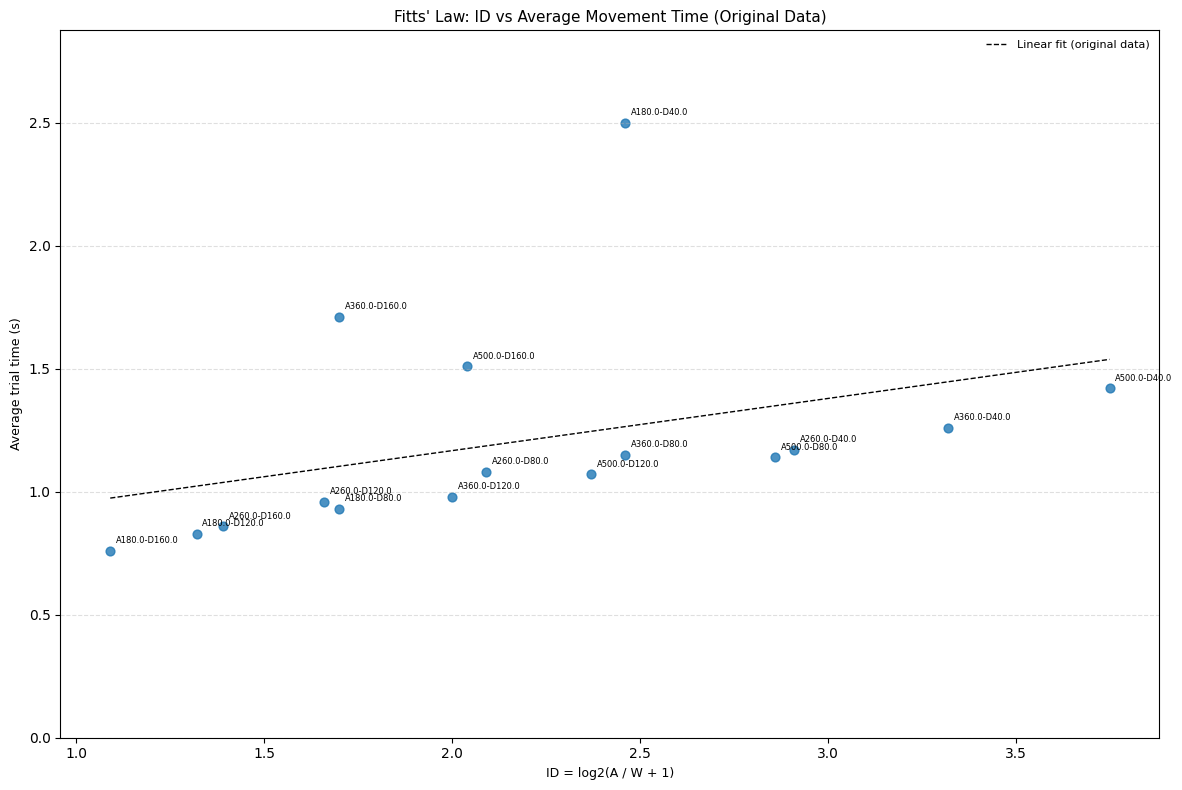

In [76]:
# If summary is a MultiIndex (amplitude_px, diameter_px), reset it:
summary_plot = summary.reset_index()

# X and y for the ORIGINAL data
x = summary_plot["ID"].values
y = summary_plot["avg_trial_time"].values

# Fit regression on original data
X = x.reshape(-1, 1)
model_orig = LinearRegression()
model_orig.fit(X, y)

# Prepare line
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = model_orig.predict(x_line)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# 1) Scatter points
ax.scatter(x, y, s=40, alpha=0.8)

# 2) Regression line (original data)
ax.plot(
    x_line,
    y_line,
    color="#020202",
    linewidth=1,
    linestyle="--",
    label="Linear fit (original data)"
)

# 3) Labels for each (A, D) group
for _, row in summary_plot.iterrows():
    label = f'A{row["amplitude_px"]}-D{row["diameter_px"]}'
    ax.annotate(
        label,
        (row["ID"], row["avg_trial_time"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=6,
        ha="left",
        va="bottom"
    )

# 4) Axes, title, legend
ax.set_xlabel("ID = log2(A / W + 1)", fontsize=9)
ax.set_ylabel("Average trial time (s)", fontsize=9)
ax.set_title("Fitts' Law: ID vs Average Movement Time (Original Data)", fontsize=11)

# 5) Y-limit and grid
y_max = y.max()
ax.set_ylim(0, y_max * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.margins(x=0.05)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# IQR outlier handling

In [77]:
target_col = "trial_time_s"

df_clean = df.copy()

def replace_outliers(group):
    # if group too small, skip
    if len(group) < 2:
        return group

    q1 = group[target_col].quantile(0.25)
    q3 = group[target_col].quantile(0.75)
    iqr = q3 - q1

    # if no spread, nothing to do
    if iqr == 0:
        return group

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_outlier = (group[target_col] < lower) | (group[target_col] > upper)

    # replace outliers with group median (or mean if you prefer)
    replacement = group[target_col].median()
    group.loc[mask_outlier, target_col] = replacement

    return group

df_clean = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"], group_keys=False)
    .apply(replace_outliers)
)

/tmp/ipython-input-2020637556.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(replace_outliers)


In [78]:
import numpy as np
import matplotlib.pyplot as plt

df_clean["ID"] = np.log2(df_clean["amplitude_px"] / df_clean["diameter_px"] + 1)

# 2. Summary table
summary_clean = (
    df_clean.groupby(["amplitude_px", "diameter_px"])
      .agg(
          avg_trial_time=("trial_time_s", "mean"),
          avg_path_distance=("path_distance_px", "mean"),
          total_errors=("errors", "sum"),
          n_trials=("errors", "count"),
          ID=("ID", "mean")
      )
)

summary_clean["error_rate"] = summary_clean["total_errors"]*100 / (summary_clean["n_trials"]*15)

# 3. Move index to columns
summary_clean = summary_clean.reset_index()

# 4.  rename error_rate to Error_Rate
summary_clean["Error_Rate"] = summary_clean["error_rate"]

# 5. Keep and order the columns you want
summary_clean = summary_clean[
    ["diameter_px", "amplitude_px","ID",
     "avg_trial_time", "avg_path_distance", "Error_Rate"]
]

# 6. Round last three numeric columns to 3 decimals
cols_to_round = ["avg_trial_time", "avg_path_distance", "Error_Rate", "ID"]
summary_clean[cols_to_round] = summary_clean[cols_to_round].round(2)

summary_clean

,diameter_px,amplitude_px,ID,avg_trial_time,avg_path_distance,Error_Rate
0,40,180,2.46,1.05,239.16,1.33
1,80,180,1.70,0.88,221.09,1.24
2,120,180,1.32,0.79,191.17,1.44
3,160,180,1.09,0.73,195.67,1.00
4,40,260,2.91,1.12,322.14,1.49
5,80,260,2.09,0.96,310.96,1.56
6,120,260,1.66,0.87,295.50,1.07
7,160,260,1.39,0.81,269.50,1.16
8,40,360,3.32,1.17,433.74,1.29
9,80,360,2.46,1.02,415.83,1.38


# Explore relationship between index of difficulty ID vs time

In [79]:
import numpy as np
import pandas as pd

df_clean["ID"] = np.log2(df_clean["amplitude_px"] / df_clean["diameter_px"] + 1)

summary_clean = (
    df_clean.groupby(["amplitude_px", "diameter_px"])
      .agg(
          avg_trial_time=("trial_time_s", "mean"),
          ID=("ID", "mean")
      )
).reset_index()

from sklearn.linear_model import LinearRegression
import numpy as np

X = summary_clean[["ID"]].values     # predictor
y = summary_clean["avg_trial_time"].values  # target

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (b):", slope)
print("Intercept (a):", intercept)

Slope (b): 0.1949630280563559
Intercept (a): 0.5415504202084538


### Fit a regression line

In [15]:
import statsmodels.api as sm

# Dependent variable
y = df_clean["trial_time_s"].astype(float)

# Independent variable
X = df_clean[["ID"]].astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit model
model_id = sm.OLS(y, X).fit()

print(model_id.summary())

                            OLS Regression Results                            
Dep. Variable:           trial_time_s   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     1709.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          7.77e-320
Time:                        05:36:02   Log-Likelihood:                 135.48
No. Observations:                4800   AIC:                            -267.0
Df Residuals:                    4798   BIC:                            -254.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5416      0.011     49.701      0.0

### Visualize the regression line to scatter plot

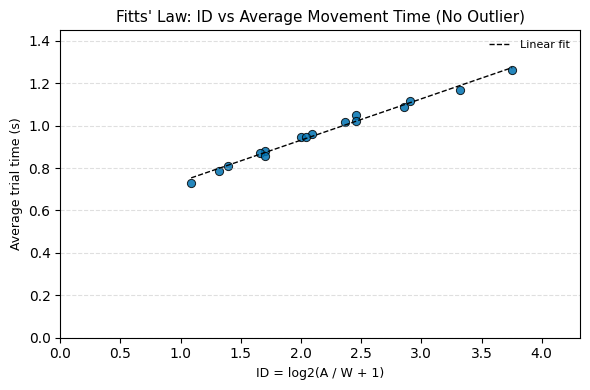

In [80]:
import numpy as np
import matplotlib.pyplot as plt



x = summary_clean["ID"].values
y = summary_clean["avg_trial_time"].values

fig, ax = plt.subplots(figsize=(6, 4))

# 1) Scatter: bigger markers, nicer color, slight transparency
scatter = ax.scatter(
    x,
    y,
    s=35,
    color="#0072B2",          # blue
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

# 2) Regression line (Fitts' law fit)
x_line = np.linspace(summary_clean["ID"].min(), summary_clean["ID"].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax.plot(
    x_line,
    y_line,
    color="#020202",
    linewidth=1,
    linestyle="--",
    label="Linear fit"
)

# # 3) Labels for each (A, D) group, slightly offset
# for _, row in summary_plot.iterrows():
#     label = f'A{row["amplitude_px"]}-D{row["diameter_px"]}'
#     ax.annotate(
#         label,
#         (row["ID"], row["avg_trial_time"]),
#         textcoords="offset points",
#         xytext=(3, 3),         # offset in points
#         ha="left",
#         va="bottom",
#         fontsize=6
#     )

# 4) Axes, title, legend
ax.set_xlabel("ID = log2(A / W + 1)", fontsize=9)
ax.set_ylabel("Average trial time (s)", fontsize=9)
ax.set_title("Fitts' Law: ID vs Average Movement Time (No Outlier)", fontsize=11)

# optional: a bit of extra headroom on y-axis
y_max = y.max()
x_max = x.max()
ax.set_ylim(0, y_max * 1.15)
ax.set_xlim(0, x_max * 1.15)
# 5) Grid and margins
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.margins(x=0.05)

ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


# Right direction data

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Recompute ID on the clean dataframe (if not already there)
df_clean["ID"] = np.log2(df_clean["amplitude_px"] / df_clean["diameter_px"] + 1)

# 1a. Keep only right-direction trials
df_right = df_clean[df_clean["direction"] == "right"].copy()

# 2. Summary table from the RIGHT-ONLY data
summary_clean_right = (
    df_right.groupby(["amplitude_px", "diameter_px"])
            .agg(
                avg_trial_time=("trial_time_s", "mean"),
                avg_path_distance=("path_distance_px", "mean"),
                total_errors=("errors", "sum"),
                n_trials=("errors", "count"),
                ID=("ID", "mean")
            )
            .reset_index()   # <-- make amplitude_px, diameter_px columns
)

# Error rate as percentage of trials
summary_clean_right["Error_Rate"] = (
    summary_clean_right["total_errors"] * 100.0 / summary_clean_right["n_trials"]
)

# Keep and order columns
summary_clean_right = summary_clean_right[
    ["diameter_px", "amplitude_px", "ID",
     "avg_trial_time", "avg_path_distance", "Error_Rate"]
]

# Round selected columns
cols_to_round = ["avg_trial_time", "avg_path_distance", "Error_Rate", "ID"]
summary_clean_right[cols_to_round] = summary_clean_right[cols_to_round].round(2)

# 3. Use this for plots
summary_plot_right = summary_clean_right.copy()

summary_clean_right



,diameter_px,amplitude_px,ID,avg_trial_time,avg_path_distance,Error_Rate
0,40,180,2.46,1.07,231.97,16.67
1,80,180,1.70,0.90,228.00,19.33
2,120,180,1.32,0.79,192.55,25.33
3,160,180,1.09,0.74,205.18,16.67
4,40,260,2.91,1.12,330.89,20.67
5,80,260,2.09,0.97,310.17,24.67
6,120,260,1.66,0.86,293.35,13.33
7,160,260,1.39,0.81,280.32,17.33
8,40,360,3.32,1.15,438.01,16.00
9,80,360,2.46,1.01,421.24,22.67


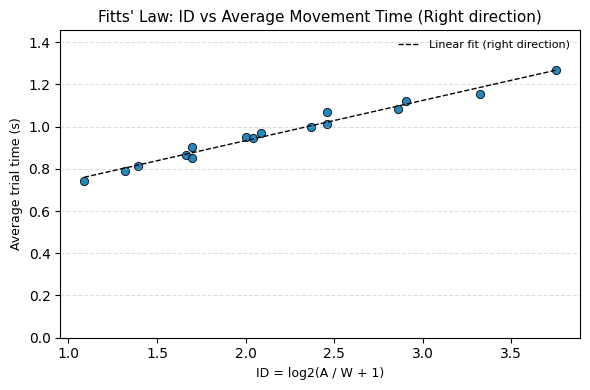

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Keep only right-direction trials
df_right = df_clean[df_clean["direction"] == "right"].copy()

# 2) Recompute ID for safety (if already present, this just overwrites)
df_right["ID"] = np.log2(df_right["amplitude_px"] / df_right["diameter_px"] + 1)

# 3) Summary table for RIGHT direction only
summary_clean_right = (
    df_right.groupby(["amplitude_px", "diameter_px"])
            .agg(
                avg_trial_time=("trial_time_s", "mean"),
                avg_path_distance=("path_distance_px", "mean"),
                total_errors=("errors", "sum"),
                n_trials=("errors", "count"),
                ID=("ID", "mean")
            )
)

summary_clean_right["error_rate"] = (
    summary_clean_right["total_errors"] / summary_clean_right["n_trials"]
)

summary_plot_right = summary_clean_right.reset_index()

# 4) Linear regression: MT vs ID (right direction only)
X_r = summary_plot_right[["ID"]].values
y_r = summary_plot_right["avg_trial_time"].values

model_right = LinearRegression()
model_right.fit(X_r, y_r)

# 5) Styled plot (same style as your previous one)
x = summary_plot_right["ID"].values
y = summary_plot_right["avg_trial_time"].values

fig, ax = plt.subplots(figsize=(6, 4))

# Scatter
scatter = ax.scatter(
    x,
    y,
    s=35,
    color="#0072B2",          # blue
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

# Regression line
x_line = np.linspace(summary_clean_right["ID"].min(),
                     summary_clean_right["ID"].max(), 100)
y_line = model_right.predict(x_line.reshape(-1, 1))
ax.plot(
    x_line,
    y_line,
    color="#020202",
    linewidth=1,
    linestyle="--",
    label="Linear fit (right direction)"
)

ax.set_xlabel("ID = log2(A / W + 1)", fontsize=9)
ax.set_ylabel("Average trial time (s)", fontsize=9)
ax.set_title("Fitts' Law: ID vs Average Movement Time (Right direction)", fontsize=11)

y_max = y.max()
ax.set_ylim(0, y_max * 1.15)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.margins(x=0.05)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# Left direction data

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Recompute ID on the clean dataframe (if not already there)
df_clean["ID"] = np.log2(df_clean["amplitude_px"] / df_clean["diameter_px"] + 1)

# 1a. Keep only LEFT-direction trials
df_left = df_clean[df_clean["direction"] == "left"].copy()

# 2. Summary table from the LEFT-ONLY data
summary_clean_left = (
    df_left.groupby(["amplitude_px", "diameter_px"])
           .agg(
               avg_trial_time=("trial_time_s", "mean"),
               avg_path_distance=("path_distance_px", "mean"),
               total_errors=("errors", "sum"),
               n_trials=("errors", "count"),
               ID=("ID", "mean")
           )
           .reset_index()   # <-- make amplitude_px, diameter_px columns
)

# Error rate as percentage of trials
summary_clean_left["Error_Rate"] = (
    summary_clean_left["total_errors"] * 100.0 / (summary_clean_left["n_trials"]*15)
)

# Keep and order columns
summary_clean_left = summary_clean_left[
    ["diameter_px", "amplitude_px", "ID",
     "avg_trial_time", "avg_path_distance", "Error_Rate"]
]

# Round selected columns
cols_to_round = ["avg_trial_time", "avg_path_distance", "Error_Rate", "ID"]
summary_clean_left[cols_to_round] = summary_clean_left[cols_to_round].round(2)

# 3. Use this for plots
summary_plot_left = summary_clean_left.copy()

summary_clean_left

,diameter_px,amplitude_px,ID,avg_trial_time,avg_path_distance,Error_Rate
0,40,180,2.46,1.03,246.36,1.56
1,80,180,1.70,0.86,214.18,1.20
2,120,180,1.32,0.79,189.78,1.20
3,160,180,1.09,0.72,186.17,0.89
4,40,260,2.91,1.12,313.39,1.60
5,80,260,2.09,0.95,311.75,1.47
6,120,260,1.66,0.88,297.64,1.24
7,160,260,1.39,0.80,258.68,1.16
8,40,360,3.32,1.18,429.47,1.51
9,80,360,2.46,1.03,410.42,1.24


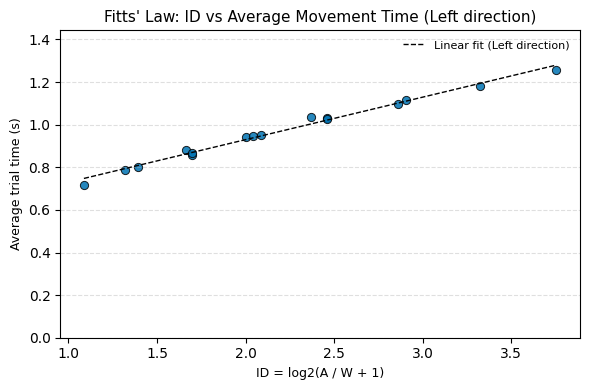

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Keep only right-direction trials
df_left = df_clean[df_clean["direction"] == "left"].copy()

# 2) Recompute ID for safety (if already present, this just overwrites)
df_left["ID"] = np.log2(df_left["amplitude_px"] / df_left["diameter_px"] + 1)

# 3) Summary table for RIGHT direction only
summary_clean_left = (
    df_left.groupby(["amplitude_px", "diameter_px"])
            .agg(
                avg_trial_time=("trial_time_s", "mean"),
                avg_path_distance=("path_distance_px", "mean"),
                total_errors=("errors", "sum"),
                n_trials=("errors", "count"),
                ID=("ID", "mean")
            )
)

summary_clean_left["error_rate"] = (
    summary_clean_left["total_errors"]*100 / (summary_clean_left["n_trials"]*15)
)

summary_plot_right = summary_clean_left.reset_index()

# 4) Linear regression: MT vs ID (right direction only)
X_r = summary_plot_right[["ID"]].values
y_r = summary_plot_right["avg_trial_time"].values

model_right = LinearRegression()
model_right.fit(X_r, y_r)

# 5) Styled plot (same style as your previous one)
x = summary_plot_right["ID"].values
y = summary_plot_right["avg_trial_time"].values

fig, ax = plt.subplots(figsize=(6, 4))

# Scatter
scatter = ax.scatter(
    x,
    y,
    s=35,
    color="#0072B2",          # blue
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

# Regression line
x_line = np.linspace(summary_clean_right["ID"].min(),
                     summary_clean_right["ID"].max(), 100)
y_line = model_right.predict(x_line.reshape(-1, 1))
ax.plot(
    x_line,
    y_line,
    color="#020202",
    linewidth=1,
    linestyle="--",
    label="Linear fit (Left direction)"
)

ax.set_xlabel("ID = log2(A / W + 1)", fontsize=9)
ax.set_ylabel("Average trial time (s)", fontsize=9)
ax.set_title("Fitts' Law: ID vs Average Movement Time (Left direction)", fontsize=11)

y_max = y.max()
ax.set_ylim(0, y_max * 1.15)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.margins(x=0.05)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# Compare regression line for total data, right direction and left direction


All  : MT ≈ 0.195·ID + 0.542
Left : MT ≈ 0.199·ID + 0.531
Right: MT ≈ 0.190·ID + 0.552


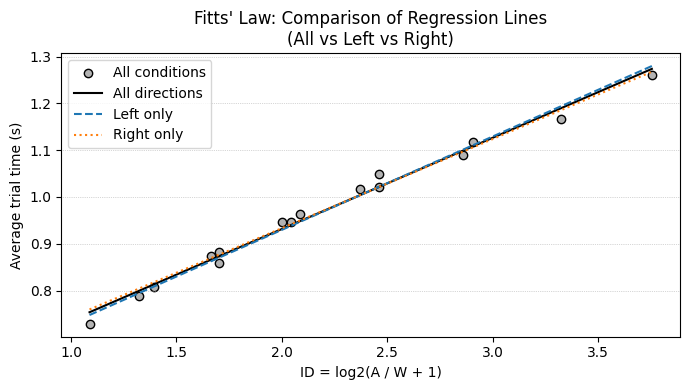

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1. Condition-level averages ----------

# All directions together
summary_all = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        avg_trial_time=("trial_time_s", "mean"),
        ID=("ID", "mean")
    )
    .reset_index()
)

# Left-only trials
summary_left = (
    df_clean[df_clean["direction"] == "left"]
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        avg_trial_time=("trial_time_s", "mean"),
        ID=("ID", "mean")
    )
    .reset_index()
)

# Right-only trials
summary_right = (
    df_clean[df_clean["direction"] == "right"]
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        avg_trial_time=("trial_time_s", "mean"),
        ID=("ID", "mean")
    )
    .reset_index()
)

# ---------- 2. Fit regression lines (MT = a + b·ID) ----------

# All
b_all, a_all = np.polyfit(summary_all["ID"], summary_all["avg_trial_time"], 1)
# Left
b_left, a_left = np.polyfit(summary_left["ID"], summary_left["avg_trial_time"], 1)
# Right
b_right, a_right = np.polyfit(summary_right["ID"], summary_right["avg_trial_time"], 1)

print(f"All  : MT ≈ {b_all:.3f}·ID + {a_all:.3f}")
print(f"Left : MT ≈ {b_left:.3f}·ID + {a_left:.3f}")
print(f"Right: MT ≈ {b_right:.3f}·ID + {a_right:.3f}")

# x range for plotting lines
x_line = np.linspace(summary_all["ID"].min(), summary_all["ID"].max(), 200)

# ---------- 3. Plot ----------

plt.figure(figsize=(7, 4))

# Scatter of all condition means
plt.scatter(
    summary_all["ID"],
    summary_all["avg_trial_time"],
    color="0.7",
    edgecolor="black",
    label="All conditions"
)

# Regression lines
plt.plot(x_line, a_all + b_all * x_line, color="black", label="All directions")
plt.plot(x_line, a_left + b_left * x_line, linestyle="--", color="tab:blue", label="Left only")
plt.plot(x_line, a_right + b_right * x_line, linestyle=":", color="tab:orange", label="Right only")

plt.xlabel("ID = log2(A / W + 1)")
plt.ylabel("Average trial time (s)")
plt.title("Fitts' Law: Comparison of Regression Lines\n(All vs Left vs Right)")
plt.legend()
plt.grid(axis="y", linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()

# Index of Difficulty vs Age

---



In [86]:
avg_time_by_age = (
    df_clean
    .groupby("age")["trial_time_s"]
    .mean()
    .sort_index()
)

print(avg_time_by_age)

age
18    0.786325
19    1.174817
20    0.822896
21    0.984394
22    1.180397
23    0.982859
24    0.967584
30    1.089692
34    0.896659
37    1.059129
Name: trial_time_s, dtype: float64


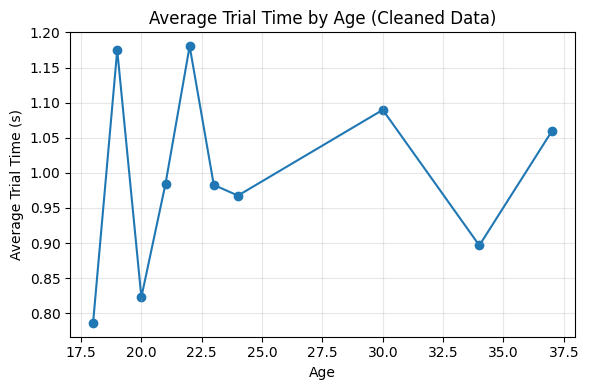

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(avg_time_by_age.index, avg_time_by_age.values)

plt.plot(avg_time_by_age.index, avg_time_by_age.values)   # optional line

plt.xlabel("Age")
plt.ylabel("Average Trial Time (s)")
plt.title("Average Trial Time by Age (Cleaned Data)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Index of Difficulty vs Handedness


proficiency
Casual user         0.938009
Power user          0.824978
Rarely use mouse    0.993433
Regular user        1.036507
Name: trial_time_s, dtype: float64


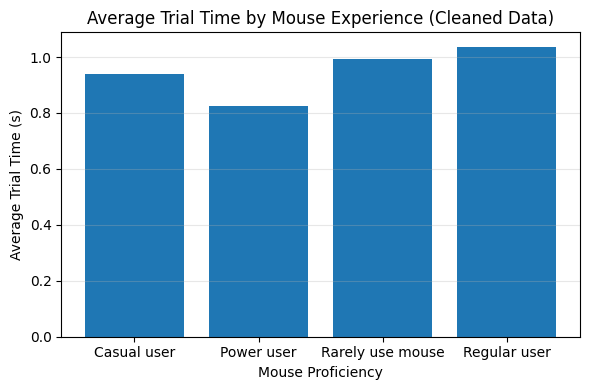

In [88]:
avg_time_by_experience = (
    df_clean
    .groupby("proficiency")["trial_time_s"]
    .mean()
    .sort_index()
)

print(avg_time_by_experience)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(avg_time_by_experience.index, avg_time_by_experience.values)

plt.xlabel("Mouse Proficiency")
plt.ylabel("Average Trial Time (s)")
plt.title("Average Trial Time by Mouse Experience (Cleaned Data)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

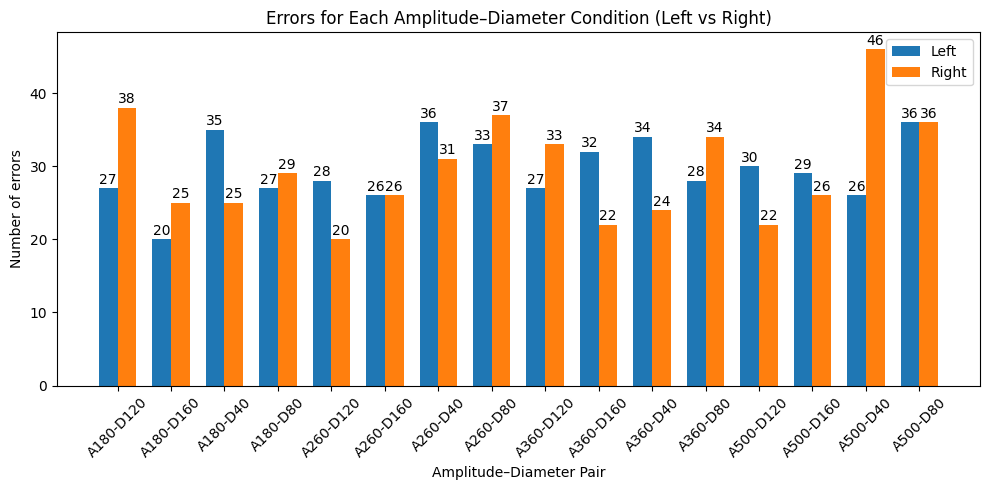

In [90]:

# 1. Group by amplitude, diameter, and direction
err_pairs = (
    df_clean
    .groupby(["amplitude_px", "diameter_px", "direction"])
    .agg(total_errors=("errors", "sum"))
    .reset_index()
)

# 2. Create a combined label for x-axis
err_pairs["label"] = (
    "A" + err_pairs["amplitude_px"].astype(str)
    + "-D" + err_pairs["diameter_px"].astype(str)
)

# 3. Pivot so we get columns: left, right
pivot_err = err_pairs.pivot(
    index="label",
    columns="direction",
    values="total_errors"
).fillna(0)

# Ensure order is consistent
labels = pivot_err.index.tolist()
left_values = pivot_err["left"].values
right_values = pivot_err["right"].values

# 4. Plot side-by-side bars
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, left_values, width, label="Left")
plt.bar(x + width/2, right_values, width, label="Right")

plt.xticks(x, labels, rotation=45)
plt.ylabel("Number of errors")
plt.xlabel("Amplitude–Diameter Pair")
plt.title("Errors for Each Amplitude–Diameter Condition (Left vs Right)")
plt.legend()

# optional: add values above bars
for i, v in enumerate(left_values):
    plt.text(i - width/2, v + 0.2, str(int(v)), ha='center', va='bottom')

for i, v in enumerate(right_values):
    plt.text(i + width/2, v + 0.2, str(int(v)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [26]:
pivot_err


direction,left,right
label,,
A180-D120,27,38
A180-D160,20,25
A180-D40,35,25
A180-D80,27,29
A260-D120,28,20
A260-D160,26,26
A260-D40,36,31
A260-D80,33,37
A360-D120,27,33


In [92]:
from statsmodels.stats.proportion import proportions_ztest

# count errors and trials
left_errors  = df_clean[df_clean["direction"]=="left"]["errors"].sum()
right_errors = df_clean[df_clean["direction"]=="right"]["errors"].sum()

left_trials  = df_clean[df_clean["direction"]=="left"].shape[0]
right_trials = df_clean[df_clean["direction"]=="right"].shape[0]

# z-test
counts = np.array([left_errors, right_errors])
nobs   = np.array([left_trials, right_trials])

z_stat, p_value = proportions_ztest(counts, nobs)

print("Two-proportion z-test (error rate: left vs right)")
print(f"z-statistic = {z_stat:.3f}")
print(f"p-value     = {p_value:.5f}")

Two-proportion z-test (error rate: left vs right)
z-statistic = 0.000
p-value     = 1.00000


proficiency
Casual user         0.938009
Power user          0.824978
Rarely use mouse    0.993433
Regular user        1.036507
Name: trial_time_s, dtype: float64


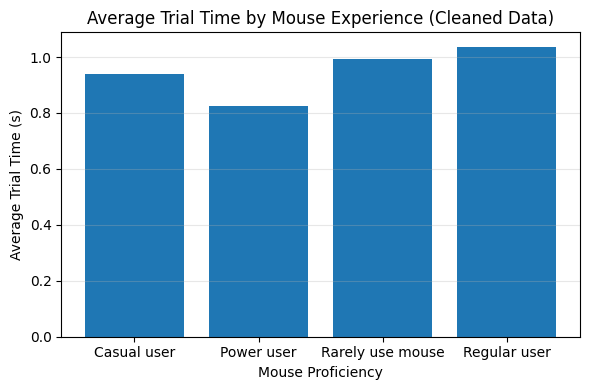

In [93]:
avg_time_by_experience = (
    df_clean
    .groupby("proficiency")["trial_time_s"]
    .mean()
    .sort_index()
)

print(avg_time_by_experience)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(avg_time_by_experience.index, avg_time_by_experience.values)

plt.xlabel("Mouse Proficiency")
plt.ylabel("Average Trial Time (s)")
plt.title("Average Trial Time by Mouse Experience (Cleaned Data)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Error rate

## **Heatmap**: Compare error rate vs combinaiton of amplitude and target distance

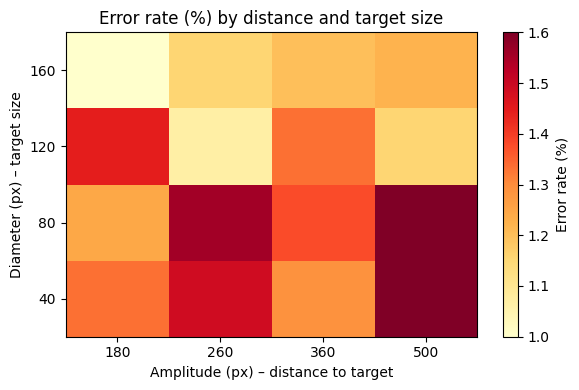

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Errors and trials by direction, amplitude, diameter
err_by_dir = (
    df_clean
    .groupby(["direction", "amplitude_px", "diameter_px"])
    .agg(
        total_errors=("errors", "sum"),
        n_trials=("errors", "count")
    )
    .reset_index()
)

# 2) Pool across directions → one error rate per (amplitude, diameter)
err_all = (
    err_by_dir
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        total_errors=("total_errors", "sum"),
        n_trials=("n_trials", "sum")
    )
    .reset_index()
)

# Error rate in percent
err_all["error_rate"] = err_all["total_errors"] * 100.0 / (err_all["n_trials"]* 15)

# 3) Pivot to amplitude × diameter grid
heat = err_all.pivot(
    index="diameter_px",   # rows
    columns="amplitude_px",# columns
    values="error_rate"
)

plt.figure(figsize=(6, 4))

im = plt.imshow(
    heat.values,
    aspect="auto",
    origin="lower",
    cmap="YlOrRd"
)

plt.xticks(
    ticks=np.arange(len(heat.columns)),
    labels=heat.columns,
)
plt.yticks(
    ticks=np.arange(len(heat.index)),
    labels=heat.index
)

plt.xlabel("Amplitude (px) – distance to target")
plt.ylabel("Diameter (px) – target size")
plt.title("Error rate (%) by distance and target size")

cbar = plt.colorbar(im)
cbar.set_label("Error rate (%)")

plt.tight_layout()
plt.show()

In [95]:
##one row per (A, W) pair
err_by_id = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        total_errors=("errors", "sum"),
        n_trials=("errors", "count")
    )
    .reset_index()
)

#  Compute ID and error rate (%)
err_by_id["ID"] = np.log2(err_by_id["amplitude_px"] / err_by_id["diameter_px"] + 1)
err_by_id["error_rate"] = err_by_id["total_errors"] * 100.0 / (err_by_id["n_trials"]* 15)

# Linear regression: error_rate ~ ID
X = sm.add_constant(err_by_id["ID"])
y = err_by_id["error_rate"]

model_err_id = sm.OLS(y, X).fit()
print(model_err_id.summary())

                            OLS Regression Results                            
Dep. Variable:             error_rate   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     9.129
Date:                Wed, 26 Nov 2025   Prob (F-statistic):            0.00915
Time:                        05:51:34   Log-Likelihood:                 8.8634
No. Observations:                  16   AIC:                            -13.73
Df Residuals:                      14   BIC:                            -12.18
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9743      0.119      8.171      0.0

### Compare error rate for amplitude and diameter not as a logaritmic function


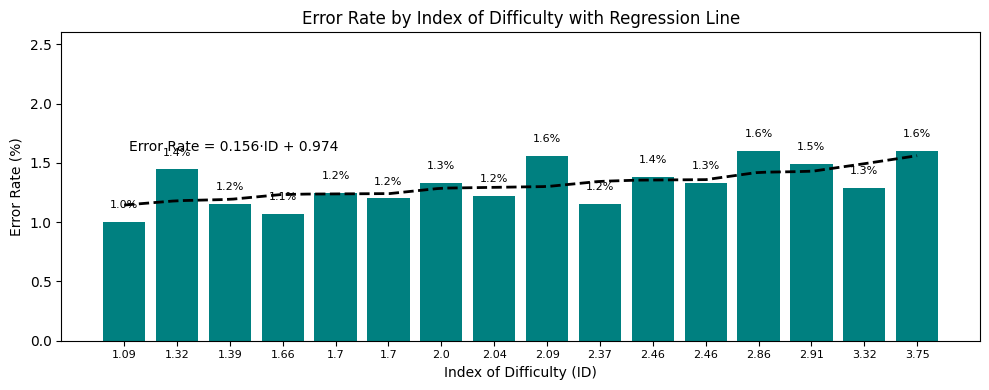

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# ---------------------------
# 1. Build summary
# ---------------------------
summary_clean = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        total_errors=("errors", "sum"),
        n_trials=("errors", "count"),
        avg_trial_time=("trial_time_s", "mean")
    )
    .reset_index()
)

summary_clean["ID"] = np.log2(summary_clean["amplitude_px"] /
                              summary_clean["diameter_px"] + 1)

summary_clean["Error_Rate"] = summary_clean["total_errors"] * 100.0 / (summary_clean["n_trials"] * 15)

df_plot = summary_clean.sort_values(by="ID").copy()
df_plot["ID_label"] = df_plot["ID"].round(2).astype(str)

# ---------------------------
# 2. Fit regression: Error Rate ~ ID
# ---------------------------
X = sm.add_constant(df_plot["ID"])
y = df_plot["Error_Rate"]

model = sm.OLS(y, X).fit()

# Create regression line values
x_line = np.linspace(df_plot["ID"].min(), df_plot["ID"].max(), 100)
X_line = sm.add_constant(x_line)
y_line = model.predict(X_line)

# ---------------------------
# 3. Plot bar chart and regression line
# ---------------------------
plt.figure(figsize=(10, 4))

# Bars
bars = plt.bar(
    np.arange(len(df_plot)),
    df_plot["Error_Rate"],
    color="teal"
)

plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Error Rate (%)")
plt.title("Error Rate by Index of Difficulty with Regression Line")

max_err = df_plot["Error_Rate"].max()
plt.ylim(0, max_err + 1)

# X-axis labels
plt.xticks(
    ticks=np.arange(len(df_plot)),
    labels=df_plot["ID_label"],
    rotation=0,
    fontsize=8
)

# Bar labels
for bar, v in zip(bars, df_plot["Error_Rate"]):
    x = bar.get_x() + bar.get_width() / 2
    yb = bar.get_height()
    plt.text(x, yb + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

# ---------------------------
# Add regression line (plotted against actual ID positions)
# ---------------------------
# Convert x-axis index positions into actual ID scale
id_positions = np.interp(x_line,
                         df_plot["ID"].values,
                         np.arange(len(df_plot)))

plt.plot(id_positions, y_line, color="black", linestyle="--", linewidth=2)

# Add equation text
a = model.params["ID"]
b = model.params["const"]
plt.text(0.1, max_err,
         f"Error Rate = {a:.3f}·ID + {b:.3f}",
         fontsize=10)

plt.tight_layout()
plt.show()

In [102]:
import statsmodels.api as sm

# X and y as before
X_sm = sm.add_constant(summary_clean[["diameter_px"]])
y_sm = summary_clean["Error_Rate"]

model_sm = sm.OLS(y_sm, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             Error_Rate   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     10.43
Date:                Wed, 26 Nov 2025   Prob (F-statistic):            0.00606
Time:                        05:52:03   Log-Likelihood:                 9.3000
No. Observations:                  16   AIC:                            -14.60
Df Residuals:                      14   BIC:                            -13.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.5778      0.089     17.812      

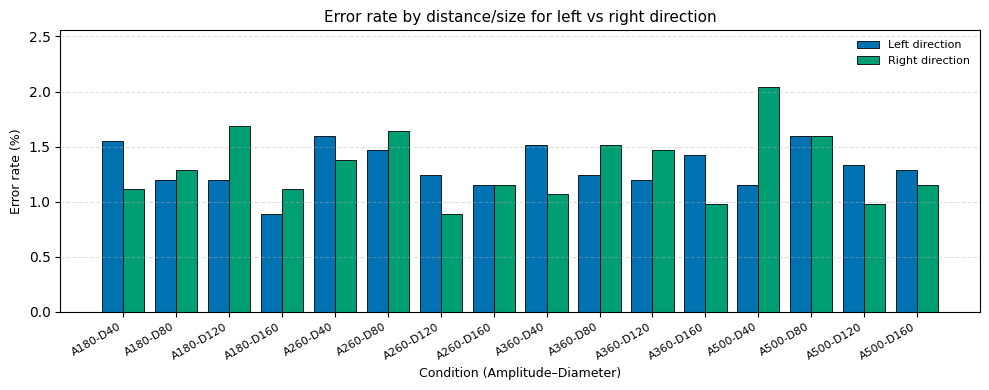

In [103]:
import numpy as np
import matplotlib.pyplot as plt
n= 15
# 1) Group and compute error rate per direction × amplitude × diameter
err_by_dir = (
    df_clean
    .groupby(["direction", "amplitude_px", "diameter_px"])
    .agg(
        total_errors=("errors", "sum"),
        n_trials=("errors", "count")
    )
    .reset_index()
)

# error rate as proportion or percent (here: percent)
err_by_dir["error_rate"] = err_by_dir["total_errors"] * 100.0 / (err_by_dir["n_trials"]* n)

# 2) Pivot so we get columns "left" and "right" for each (A, D)
err_pivot = (
    err_by_dir
    .pivot(
        index=["amplitude_px", "diameter_px"],
        columns="direction",
        values="error_rate"
    )
    .reset_index()
    .fillna(0.0)        # if some combos are missing one direction
)

# 3) Create labels for the 16 conditions
err_pivot["label"] = err_pivot.apply(
    lambda r: f"A{int(r['amplitude_px'])}-D{int(r['diameter_px'])}", axis=1
)

# 4) Side-by-side bar chart
x = np.arange(len(err_pivot))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 4))

bars_left = ax.bar(
    x - width/2,
    err_pivot["left"],
    width=width,
    label="Left direction",
    color="#0072B2",
    edgecolor="black",
    linewidth=0.6
)

bars_right = ax.bar(
    x + width/2,
    err_pivot["right"],
    width=width,
    label="Right direction",
    color="#009E73",
    edgecolor="black",
    linewidth=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(err_pivot["label"], rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Condition (Amplitude–Diameter)", fontsize=9)
ax.set_ylabel("Error rate (%)", fontsize=9)
ax.set_title("Error rate by distance/size for left vs right direction", fontsize=11)
ax.legend(fontsize=8, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ymax = max(err_pivot["left"].max(), err_pivot["right"].max())
ax.set_ylim(0, ymax * 1.25)

plt.tight_layout()
plt.show()

In [104]:
import pandas as pd
import numpy as np
from scipy import stats

# -------------------------
# 1. PREPARE LEFT/RIGHT DATA
# -------------------------

n = 15   # number of participants

err_by_dir = (
    df_clean
    .groupby(["direction", "amplitude_px", "diameter_px"])
    .agg(
        total_errors=("errors", "sum"),
        n_trials=("errors", "count")
    )
    .reset_index()
)

err_by_dir["error_rate"] = (
    err_by_dir["total_errors"] * 100.0 / (err_by_dir["n_trials"] * n)
)

# Pivot to get left and right side-by-side
err_pivot = (
    err_by_dir
    .pivot(
        index=["amplitude_px", "diameter_px"],
        columns="direction",
        values="error_rate"
    )
    .reset_index()
)

# Ensure missing values are filled (if any condition has only one direction)
err_pivot = err_pivot.fillna(0.0)

left_rates = err_pivot["left"].values
right_rates = err_pivot["right"].values

# -------------------------
# 2. PAIRED-SAMPLES T-TEST
# -------------------------

t_stat, p_val = stats.ttest_rel(left_rates, right_rates)

# Degrees of freedom
df = len(left_rates) - 1

# Mean difference
mean_diff = np.mean(left_rates - right_rates)

# Effect size (Cohen's d for paired samples)
sd_diff = np.std(left_rates - right_rates, ddof=1)
cohen_d = mean_diff / sd_diff if sd_diff != 0 else np.nan

# -------------------------
# 3. PRINT FULL REPORT
# -------------------------

print("\n===== PAIRED-SAMPLES T-TEST REPORT =====\n")

print(f"Number of paired conditions: {len(left_rates)}\n")

print("Descriptive statistics:")
print(f"  Mean (Left direction):  {np.mean(left_rates):.3f}%")
print(f"  Mean (Right direction): {np.mean(right_rates):.3f}%")
print(f"  Mean Difference:        {mean_diff:.3f}%\n")

print("Paired-samples t-test results:")
print(f"  t({df}) = {t_stat:.3f}")
print(f"  p-value = {p_val:.5f}")
print(f"  Cohen's d = {cohen_d:.3f}\n")

# -------------------------
# 4. AUTO INTERPRETATION
# -------------------------

alpha = 0.05

print("Interpretation:")
if p_val < alpha:
    direction = "higher" if mean_diff > 0 else "lower"
    print(f"  There is a significant difference between left and right movement error rates "
          f"(p = {p_val:.5f}). Left-direction errors are {direction} on average.")
else:
    print(f"  There is no significant difference between left and right movement error rates "
          f"(p = {p_val:.5f}). Movement direction did not affect pointing accuracy.")

print("\n========================================\n")


===== PAIRED-SAMPLES T-TEST REPORT =====

Number of paired conditions: 16

Descriptive statistics:
  Mean (Left direction):  1.317%
  Mean (Right direction): 1.317%
  Mean Difference:        0.000%

Paired-samples t-test results:
  t(15) = 0.000
  p-value = 1.00000
  Cohen's d = 0.000

Interpretation:
  There is no significant difference between left and right movement error rates (p = 1.00000). Movement direction did not affect pointing accuracy.




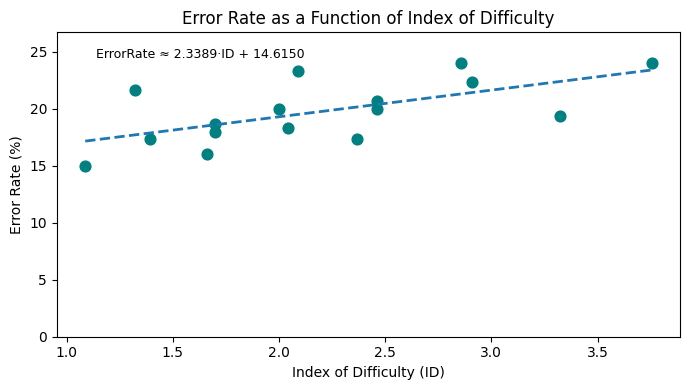

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Build condition-level table with ID and error_rate
err_all = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        ID=("ID", "mean"),                 # or recompute below if ID not in df_clean
        total_errors=("errors", "sum"),
        n_trials=("errors", "count")
    )
    .reset_index()
)

# If df_clean did NOT have an ID column, uncomment this line instead of the ID= line above:
# err_all["ID"] = np.log2(err_all["amplitude_px"] / err_all["diameter_px"] + 1)

# Error rate in percent
err_all["error_rate"] = err_all["total_errors"] * 100.0 / err_all["n_trials"]

# 2) Scatter + regression line: Error rate vs ID
x = err_all["ID"].values
y = err_all["error_rate"].values

plt.figure(figsize=(7, 4))
plt.scatter(x, y, color="teal", s=60)

# Regression line (y = a*x + b)
a, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, linestyle="--", linewidth=2)

plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Error Rate (%)")
plt.title("Error Rate as a Function of Index of Difficulty")

# Some headroom on y-axis
y_min, y_max = y.min(), y.max()
plt.ylim(0, y_max + (y_max - y_min) * 0.3)

# Show regression equation on the plot
plt.text(
    x.min() + 0.05,
    y_max + (y_max - y_min) * 0.05,
    f"ErrorRate ≈ {a:.4f}·ID + {b:.4f}",
    fontsize=9
)

plt.tight_layout()
plt.show()

# Trial Time ~ Block Number

block
1     0.986471
2     0.960067
3     0.983549
4     0.966722
5     0.976061
6     0.986810
7     0.973879
8     0.983572
9     0.946345
10    0.932343
Name: trial_time_s, dtype: float64


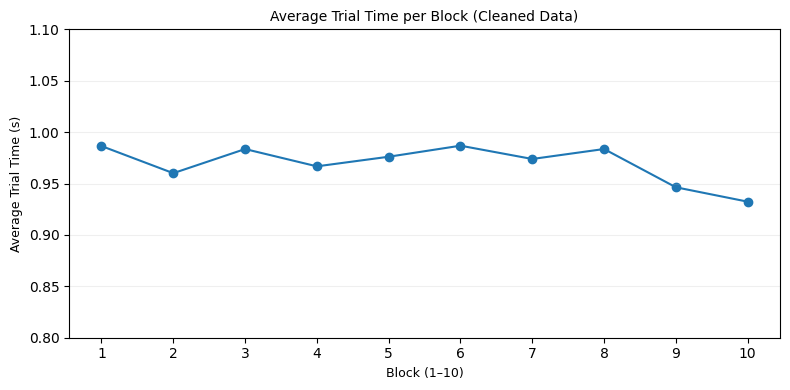

In [106]:
import matplotlib.pyplot as plt


# average trial time per block (overall)
avg_time_per_block = (
    df_clean
    .groupby("block")["trial_time_s"]
    .mean()
    .sort_index()   # ensures blocks 1..10 are in order
)

print(avg_time_per_block)


# avg_time_per_block already computed
# it is a Series indexed by block number

plt.figure(figsize=(8,4))
plt.scatter(avg_time_per_block.index, avg_time_per_block.values)

# optional: connect points with a line
plt.plot(avg_time_per_block.index, avg_time_per_block.values)

plt.xlabel("Block (1–10)", fontsize = 9)
plt.ylabel("Average Trial Time (s)", fontsize = 9)
plt.title("Average Trial Time per Block (Cleaned Data)", fontsize = 10)
plt.xticks(range(1,11))
plt.ylim(0.8, 1.1)
plt.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Linear Regression of Average Trial Time Across Blocks

In [107]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Prepare the data
X = avg_time_per_block.index.values.astype(float)  # block numbers
y = avg_time_per_block.values.astype(float)        # avg times

# Add intercept term
X_sm = sm.add_constant(X)  # creates column [1, block]

# 2. Fit regression model with statsmodels
model_sm = sm.OLS(y, X_sm).fit()

# 3. Print full regression summary
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     3.439
Date:                Wed, 26 Nov 2025   Prob (F-statistic):              0.101
Time:                        05:52:37   Log-Likelihood:                 28.060
No. Observations:                  10   AIC:                            -52.12
Df Residuals:                       8   BIC:                            -51.52
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9879      0.011     88.442      0.0

## Block Number ~ Error Rate

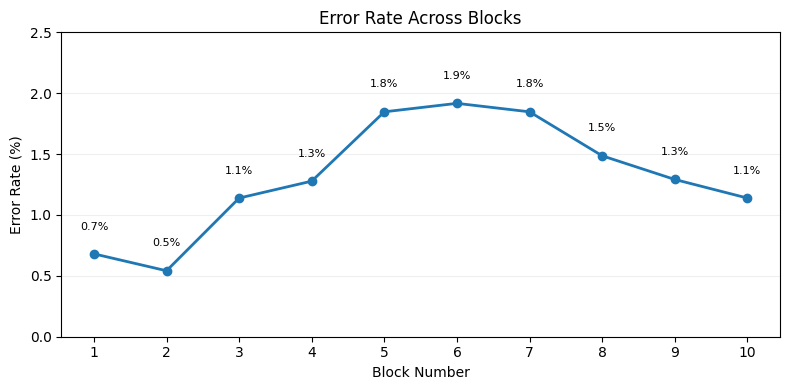

In [108]:
import matplotlib.pyplot as plt

# Compute error rate per block
df_block_err = (
    df_clean.groupby("block")
            .agg(total_errors=("errors", "sum"),
                 n_trials=("errors", "count"))
            .reset_index()
)

df_block_err["error_rate"] = 100 * df_block_err["total_errors"] / (df_block_err["n_trials"] * n)

# Line plot
plt.figure(figsize=(8, 4))
plt.plot(df_block_err["block"], df_block_err["error_rate"], marker="o", linewidth=2)

plt.xlabel("Block Number")
plt.ylabel("Error Rate (%)")
plt.title("Error Rate Across Blocks")
plt.xticks(df_block_err["block"])
plt.ylim(0, 2.5)
# Optional: show values above points
for x, y in zip(df_block_err["block"], df_block_err["error_rate"]):
    plt.text(x, y + 0.2, f"{y:.1f}%", ha="center", fontsize=8)
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [118]:
import statsmodels.api as sm


# Predictor and response
X = df_block_err["block"].values.astype(float)      # block number
y = df_block_err["error_rate"].values.astype(float) # error rate (%)

# Add intercept term
X_sm = sm.add_constant(X)   # creates [const, block]

# Fit OLS regression
model_err = sm.OLS(y, X_sm).fit()

# Print full statistical summary
print(model_err.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     2.651
Date:                Wed, 26 Nov 2025   Prob (F-statistic):              0.142
Time:                        05:59:29   Log-Likelihood:                -4.7664
No. Observations:                  10   AIC:                             13.53
Df Residuals:                       8   BIC:                             14.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8870      0.298      2.980      0.0

# Index of difficulty ~ Ratio of Actual Travelled Path to Direct Distance

In [111]:
target_col = "path_distance_px"


def replace_outliers(group):
    # if group too small, skip
    if len(group) < 2:
        return group

    q1 = group[target_col].quantile(0.25)
    q3 = group[target_col].quantile(0.75)
    iqr = q3 - q1

    # if no spread, nothing to do
    if iqr == 0:
        return group

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_outlier = (group[target_col] < lower) | (group[target_col] > upper)

    # replace outliers with group median (or mean if you prefer)
    replacement = group[target_col].median()
    group.loc[mask_outlier, target_col] = replacement

    return group

df_clean = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"], group_keys=False)
    .apply(replace_outliers)
)

/tmp/ipython-input-4108810100.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(replace_outliers)


In [112]:
import pandas as pd
import statsmodels.api as sm

# 1. Aggregate per condition
cond_summary = (
    df_clean
    .groupby(["amplitude_px", "diameter_px"])
    .agg(
        ID=("ID", "mean"),
        mean_path_distance=("path_distance_px", "mean"),
        mean_center_error=("center_to_click_px", "mean")
    )
    .reset_index()
)

# 2. Compute ratio (dependent variable)
cond_summary["ratio"] = cond_summary["mean_path_distance"] / cond_summary["mean_center_error"]


cols_to_round = ["mean_path_distance", "mean_center_error", "ratio", "ID"]
cond_summary[cols_to_round] = cond_summary[cols_to_round].round(3)


cond_summary

,amplitude_px,diameter_px,ID,mean_path_distance,mean_center_error,ratio
0,180,40,2.459,200.302,179.967,1.113
1,180,80,1.700,186.679,174.926,1.067
2,180,120,1.322,175.691,168.523,1.043
3,180,160,1.087,168.975,164.255,1.029
4,260,40,2.907,288.545,260.613,1.107
5,260,80,2.087,282.541,259.472,1.089
6,260,120,1.663,263.906,251.176,1.051
7,260,160,1.392,247.940,241.284,1.028
8,360,40,3.322,402.464,359.565,1.119
9,360,80,2.459,395.322,358.771,1.102


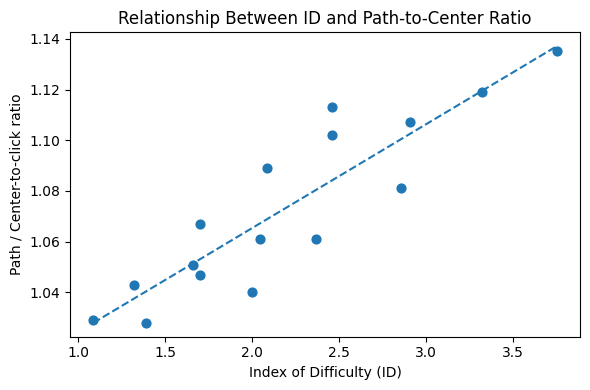

Fitted line: ratio ≈ 0.0409 * ID + 0.9836


In [113]:
import matplotlib.pyplot as plt
import numpy as np

# cond_summary must already contain columns: "ID" and "ratio"
# (ratio = mean_path_distance / mean_center_error)

x = cond_summary["ID"].values
y = cond_summary["ratio"].values

plt.figure(figsize=(6, 4))

# Scatter points
plt.scatter(x, y, s=40)

# Fit simple linear regression (y = a*x + b) for visualization
coef = np.polyfit(x, y, 1)
a, b = coef
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, linestyle="--")

plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Path / Center-to-click ratio")
plt.title("Relationship Between ID and Path-to-Center Ratio")

plt.tight_layout()
plt.show()

print(f"Fitted line: ratio ≈ {a:.4f} * ID + {b:.4f}")

In [119]:

# Define X and y
y = cond_summary["ratio"]
X = sm.add_constant(cond_summary["ID"])

# Fit regression
model = sm.OLS(y, X).fit()

# Output summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ratio   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     56.53
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.80e-06
Time:                        06:00:41   Log-Likelihood:                 44.866
No. Observations:                  16   AIC:                            -85.73
Df Residuals:                      14   BIC:                            -84.19
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9836      0.013     78.290      0.0

# Index of Difficulty ~ Mouse profeciency

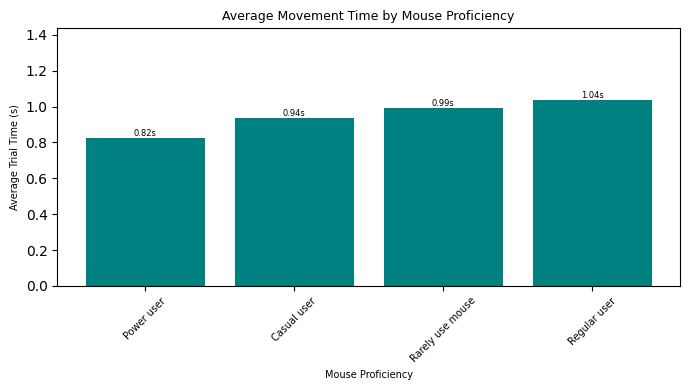

In [115]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute average movement time per proficiency level
df_prof_time = (
    df_clean.groupby("proficiency")["trial_time_s"]
            .mean()
            .reset_index()
            .sort_values("trial_time_s")
)

plt.figure(figsize=(7, 4))
bars = plt.bar(df_prof_time["proficiency"], df_prof_time["trial_time_s"], color="teal")

plt.xlabel("Mouse Proficiency", fontsize = 7)
plt.ylabel("Average Trial Time (s)", fontsize = 7)
plt.title("Average Movement Time by Mouse Proficiency", fontsize = 9)
plt.xticks(rotation=45, fontsize = 7)

# Label values above bars
for bar, v in zip(bars, df_prof_time["trial_time_s"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    plt.text(x, y + 0.01, f"{v:.2f}s", ha="center", fontsize=6)


# Set y-axis limit
max_val = df_prof_time["trial_time_s"].max()
plt.ylim(0, max_val + 0.4)   # adjust 0.1 as you like
plt.tight_layout()
plt.show()

# One-Way ANOVA: Does Mouse Proficiency Affect Movement Time




In [116]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Convert proficiency to categorical (important)
df_clean["proficiency"] = df_clean["proficiency"].astype("category")

# Fit ANOVA model
anova_model = smf.ols("trial_time_s ~ C(proficiency)", data=df_clean).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)

                    sum_sq      df           F        PR(>F)
C(proficiency)   30.039643     3.0  145.440995  3.332255e-90
Residual        330.191474  4796.0         NaN           NaN


# Final Model: Backward Regression

In [117]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------
# 1. Create "same vs opposite" factor
# ------------------------------------------------
# Adjust the string values below if your coding is slightly different.
hand = df_clean["handedness"].astype(str).str.lower()
direction = df_clean["direction"].astype(str).str.lower()

df_clean["side_condition"] = np.where(
    ((hand.str.contains("right") & direction.str.contains("right")) |
     (hand.str.contains("left")  & direction.str.contains("left"))),
    "same",
    "opposite"
)

# Optional check
print(df_clean["side_condition"].value_counts())

# ------------------------------------------------
# 2. Build modelling dataframe
# ------------------------------------------------
df_model = df_clean[[
    "trial_time_s",   # dependent
    "ID",             # numeric
    "age",            # numeric
    "proficiency",    # categorical
    "side_condition"  # categorical (same / opposite)
]].copy()

# Dummy-code categorical predictors
df_model = pd.get_dummies(
    df_model,
    columns=["proficiency", "side_condition"],
    drop_first=True        # avoids dummy trap
)

# Convert bools → int
bool_cols = df_model.select_dtypes(include=["bool"]).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Drop any remaining missing rows
df_model = df_model.dropna()

# ------------------------------------------------
# 3. Backward elimination function
# ------------------------------------------------
def backward_elimination(X, y, p_threshold=0.05):
    X = X.copy()
    X = sm.add_constant(X)

    while True:
        model = sm.OLS(y, X).fit()
        pvalues = model.pvalues.drop("const")   # ignore intercept

        max_p = pvalues.max()
        worst = pvalues.idxmax()

        if max_p < p_threshold:
            break

        print(f"Removing '{worst}' (p = {max_p:.3f})")
        X = X.drop(columns=[worst])

    return model, X

# ------------------------------------------------
# 4. Run backward elimination
# ------------------------------------------------
y = df_model["trial_time_s"].astype(float)
X = df_model.drop(columns=["trial_time_s"]).astype(float)

final_model, final_X = backward_elimination(X, y, p_threshold=0.05)

print(final_model.summary())
print("Final predictors:", final_X.columns.tolist())

side_condition
opposite    2400
same        2400
Name: count, dtype: int64
Removing 'age' (p = 0.685)
Removing 'side_condition_same' (p = 0.423)
                            OLS Regression Results                            
Dep. Variable:           trial_time_s   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     634.3
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        05:53:40   Log-Likelihood:                 423.52
No. Observations:                4800   AIC:                            -837.0
Df Residuals:                    4795   BIC:                            -804.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t    